# `E_macro` — week of 3 August 2026

**A brief, not an archive.** The evidence and the per-column detail live in
`analysis-output/E_macro_key_findings.ipynb` and the per-source findings
documents. This is what changed this week and what it means.

Every number below is read from committed artifacts in `outputs/` and
`analysis-output/`. Nothing is re-fit here.

In [1]:
import json
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd

REPO = Path.cwd().parent if Path.cwd().name == "analysis-output" else Path.cwd()
OUTPUTS, ANALYSIS = REPO / "outputs", REPO / "analysis-output"

scores = pd.read_csv(OUTPUTS / "external_target_scores.csv")
grain = pd.read_csv(OUTPUTS / "grain_effect.csv")
decile = pd.read_csv(OUTPUTS / "external_target_by_decile.csv")
ext = json.loads((ANALYSIS / "cross-source" / "external_target_stats.json").read_text())
gst = json.loads((ANALYSIS / "cross-source" / "grain_effect_stats.json").read_text())
a_tiers = json.loads((ANALYSIS / "source-a" / "source_a_tier_stats.json").read_text())
e_tiers = json.loads((ANALYSIS / "source-e" / "source_e_tier_stats.json").read_text())
scope = json.loads((ANALYSIS / "source-a" / "source_a_section_scope_stats.json").read_text())

LABELS = {
    "broadband_rate": "Broadband adoption",
    "median_household_income": "Median household income",
    "median_age": "Median age",
    "median_home_value": "Median home value",
    "mean_commute_minutes": "Mean commute",
}
ORDER = list(LABELS)
INK, BASE, LIFT, WARN = "#1f2a37", "#c7cdd6", "#2563eb", "#dc2626"

mpl.rcParams.update({
    "figure.dpi": 130, "savefig.dpi": 130,
    "font.size": 10.5, "axes.titlesize": 12.5, "axes.titleweight": "bold",
    "axes.labelcolor": INK, "text.color": INK,
    "axes.edgecolor": "#d1d5db", "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": "#6b7280", "ytick.color": "#6b7280",
    "figure.facecolor": "white", "axes.facecolor": "white",
})
print(f"{ext['n_targets']} targets · {ext['fold_strategy']} · "
      f"{gst['n_markets']} market groups")

5 targets · GroupKFold on state_fips (spatially blocked) · 208 market groups


---

## 1. The task you set on Monday: split A and E into groups

Both pillars got cut into four groups and pushed on. Short version: **the groups are
worth a great deal as a diagnostic and nothing as an architecture** — and in Source
E's case they changed what I think the pillar is actually measuring.

### Source A — four content tiers

Counties split on how much text their Wikipedia intro has: **stub** (<100 chars),
**thin** (100–283), **mid** (284–461), **rich** (≥462).

The corpus turns out to be wildly uneven, and the unevenness is economic rather than
editorial. Named industry content appears in **1.1% of thin-tier counties and 25.2%
of rich-tier ones** — a 23× gradient — while fewer than one county in ten carries any
at all. That is the fact that killed the dense-embedding approach: averaging 1,024
dimensions over 3,144 articles produces a vector dominated by counties that say
nothing economic.

So the tiers earned their keep immediately — they identified *industry* as the feature
family worth extracting, and justified refetching article sections for the counties
where the intro says least.

### Then the stronger version of the ask: should the tiers branch the model?

Splitting into groups to *look* at them is one thing; letting each group get its own
model is the real question, and it hadn't been tested. Both forms, same 28 targets,
same folds, same seed:

| approach | width | mean R² lift |
|---|---|---|
| one model, one global coefficient per feature | 29 | **+0.00307** |
| one model, coefficients free to vary by tier | 120 | +0.00279 |
| four independent models, one per tier | 29 × 4 fits | **−0.01595** |

#### What "a model" is here

Each of the 28 targets is a feature belonging to one of the other five pillars, and
every target is scored the same way:

1. **Control first.** Ordinary least squares on three size measures
   (`log_population`, `log_agi`, `log_gdp_latest`) plus one dummy per state.
   Deliberately unpenalized — ~50 controls against 3,144 rows has nothing to
   regularize, and shrinking them would let a wide Source A block degrade them.
2. **Source A predicts only what the control missed.** Its 29 columns are fit to the
   control's *residual*: median-impute → standardize → ridge, with the penalty chosen
   by an inner 5-fold search over 10⁰–10⁶.
3. **Score = out-of-fold R² gain over the control.** Outer 5-fold, shuffled, seed 42.

Only step 2 changes across the three rows of the table:

- **Flat, 29 columns.** One ridge over all 3,144 counties, one coefficient per
  feature. A stub county and a rich county share every slope.
- **Tier-crossed, 120 columns.** Four tier dummies, plus each of the 29 features
  copied into four slots — populated in the county's own tier's slot and zero
  everywhere else. Every tier gets its own slope *and* its own intercept, but there
  is still **one fit and one shared penalty**, so a tier with nothing to say gets
  shrunk toward zero using evidence pooled from the tiers that do.
- **Four independent fits.** The corpus is partitioned by tier and a separate ridge
  is fit inside each partition, each selecting its own penalty on its own rows:
  **294 / 1,274 / 788 / 788** counties. No pooling, no shared shrinkage; predictions
  are stitched back together only for scoring.

That third row is the literal reading of "handle each group differently," and it is
the one that goes negative. Two structural reasons. The stub tier's 294 counties
contain almost no industry content, so its private fit has nothing to find and no
shared penalty pulling its coefficients toward zero — it contributes noise across its
whole slice. And every tier loses the ability to borrow strength: a slope estimated
on 788 rich counties can no longer inform the 788 mid ones.

**One detail worth keeping straight**, because it is the difference between a real
tier effect and an artifact: the per-tier *results* reported elsewhere come from
evaluating the single global model's out-of-fold predictions on tier subsets, never
from refitting per tier. Otherwise "this tier is more predictable" gets confused with
"this tier got its own model."

*Caveat on the table: the first two rows are the 2026-08-04 re-score against Census
population; the third was measured once against the retired baseline and not re-run,
since a result that far negative does not turn on a fourth-decimal baseline change.*

**Both branching forms lose, and the loss scales with how much branching there is.**
Tier-specific slopes cost 9% of the lift. Fully separate per-tier models go negative —
worse than dropping Source A altogether — because each trains on roughly a quarter of
the rows and overfits with no shared penalty to restrain it.

The mechanism is ordinary bias–variance: crossing 29 features with 4 tiers puts 120
columns against targets whose smallest sample is n ≈ 1,026, and the ridge penalty big
enough to control that width over-shrinks the coefficients that were doing the work.

**Conclusion, stated carefully because it inverts easily:** the tiers are the right
diagnostic and the wrong architecture. Heterogeneity is better handled by features that
are simply *absent* when a county has nothing to say — sparsity already encodes the
tier — than by partitioning the fit. One uniform schema, one model, and the negative
result kept as a scored variant so it stays reproducible rather than becoming folklore.

### A question the tiers raise: should we read *more* of the page for thin counties?

Worth being precise about what the pipeline consumes, because the tiers turn out to
control it without anyone deciding they should. Every county gets the same treatment
— read the lead, plus any section whose title marks it economic — but what that
yields is wildly unequal:

| tier | median lead chars | has an economy section | econ chars when present | mean total chars used |
|---|---|---|---|---|
| stub | 70 | 10.5% | 405 | **127** |
| thin | 191 | 14.2% | 445 | **303** |
| mid | 354 | 21.2% | 564 | **588** |
| rich | 686 | 35.7% | 1,001 | **1,267** |

Rich counties give up ~10× the text a stub county does, and account for 57% of all
economy-section text read despite being 25% of the corpus. Meanwhile the whole
pipeline reads about 2.0M characters out of ~56M already downloaded and sitting in
`data/source_a_sections.parquet`.

**The tempting move is to read deeper only for thin counties. I think that is a
trap**, and it is the same trap as branching the model. Tier tracks county size, so a
tier-conditional rule would make `has_agriculture` mean "named in the lead or economy
section" for one county and "named anywhere on the page" for another — with the
difference correlated with population. That is a size proxy manufactured inside the
feature, in a project whose central open question is whether size is a control or a
target.

So I widened the scope **uniformly** and measured it instead
(`scripts/analyze_source_a_section_scope.py`, four scopes, same 28 targets, same
protocol — the shipped whitelist reproduces +0.00307 exactly, which is the new
harness agreeing with the old one):

| scope | mean lift | coverage | paired *p* | new hits in historical framing |
|---|---|---|---|---|
| economy-titled only *(shipped)* | +0.00307 | 18.8% | — | — |
| \+ transportation, government, infrastructure | +0.00312 | 21.6% | 0.76 | 22% |
| everything except History and Notable People | +0.00351 | 42.5% | 0.22 | 38% |
| every section | **+0.00403** | 55.2% | **0.048** | **67%** |

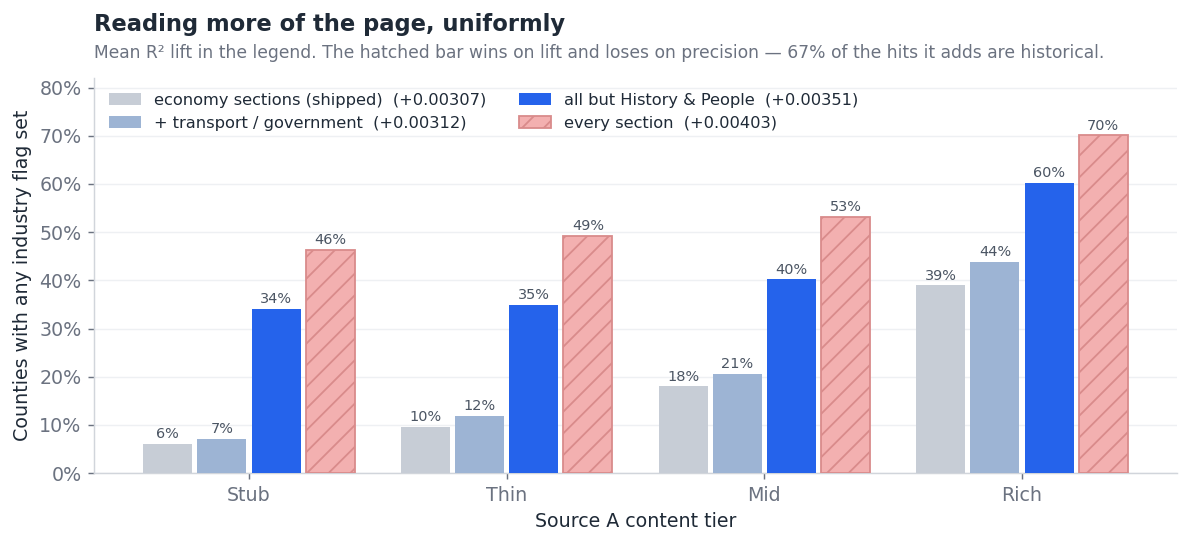

In [2]:
a_lab = a_tiers["tier_labels"]
cov = pd.DataFrame(scope["coverage_by_tier"])
SCOPE_ORDER = ["economy", "economy_plus", "no_narrative", "all_sections"]
SCOPE_LABEL = {"economy": "economy sections (shipped)",
               "economy_plus": "+ transport / government",
               "no_narrative": "all but History & People",
               "all_sections": "every section"}
SCOPE_COLOR = {"economy": "#c7cdd6", "economy_plus": "#9db4d4",
               "no_narrative": "#2563eb", "all_sections": "#f3b0b0"}
piv = cov.pivot(index="tier", columns="scope", values="coverage").reindex(a_lab)

fig, ax = plt.subplots(figsize=(9.6, 4.3))
x = range(len(a_lab))
for k, key in enumerate(SCOPE_ORDER):
    off = (k - 1.5) * 0.21
    vals = piv[key]
    ax.bar([i + off for i in x], vals, width=0.19, color=SCOPE_COLOR[key],
           label=f"{SCOPE_LABEL[key]}  ({scope['scopes'][key]['mean_lift']:+.5f})",
           zorder=3, hatch="//" if key == "all_sections" else None,
           edgecolor="#d98b8b" if key == "all_sections" else "none")
    for i, v in enumerate(vals):
        ax.text(i + off, v + 0.012, f"{v:.0%}", ha="center", fontsize=8, color="#4b5563")

ax.set_xticks(list(x), [t.capitalize() for t in a_lab])
ax.set_xlabel("Source A content tier")
ax.set_ylabel("Counties with any industry flag set")
ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax.set_ylim(0, 0.82)
ax.set_title("Reading more of the page, uniformly", pad=26, loc="left")
ax.text(0, 1.05, "Mean R² lift in the legend. The hatched bar wins on lift and loses on "
        "precision — 67% of the hits it adds are historical.",
        transform=ax.transAxes, fontsize=9.5, color="#6b7280")
ax.legend(frameon=False, fontsize=9, loc="upper left", ncol=2)
ax.grid(axis="y", color="#eef0f3", zorder=0)
plt.tight_layout()
plt.show()

**Reading more does help, and my hand-picked widening was the wrong guess.** Adding
Transportation and Government bought nothing (+0.00005, *p* = 0.76). The value sits in
sections I would not have nominated — Geography carries "planar areas largely devoted
to agriculture", Recreation carries tourism.

**But half of the winning number is history.** Reading everything is the only scope
that clears *p* < 0.05, and it gets there partly on History and Notable People, where
a sampled precision check flags **67%** of the added hits as historically framed:
*"The South Bronx was a manufacturing center for many years"*; a county "settled
between 1870 and 1880 as a ranching hub"; an oil flag set by a driller born in 1819.
Those genuinely predict current industry — industrial history correlates with present
industry — but shipping them makes `has_manufacturing` a defunct-industry detector
wearing a current-economy label, and the feature-store documentation would be wrong.

Drop the narrative sections and **+0.00044 of the +0.00096 survives**, with the
biggest movers exactly the interpretable ones: Arts & Recreation LQ, Wholesale Trade,
Accommodation & Food, capital-to-wage.

**Two things this settles.** The thin tiers do get most of the relative benefit —
stub coverage goes 6.1% → 34.0% and thin 9.7% → 34.9%, against rich's 39.0% → 60.3%
— and they get it from a *uniform* rule, so the tier-conditional version buys nothing
it doesn't also poison. And the shipped whitelist is now measured rather than
asserted.

**What this does not settle: whether to ship it.** +0.00044 at *p* = 0.22 is inside
the noise band this pillar operates in, on the same underpowered paired test that
§14.2a already flagged. The honest status is *measured, promising, not demonstrated* —
it would need a human-labelled precision sample rather than my regex heuristic, and
probably a recency filter, before it earns a schema change. Nothing was rewritten.

### Source E — four volume tiers, and a finding I did not expect

Counties split on `num_returns`: **T1** (<2.2k), **T2** (2.2k–11.7k), **T3**
(11.7k–100k), **T4** (≥100k). Here the groups did more than guide feature choice.

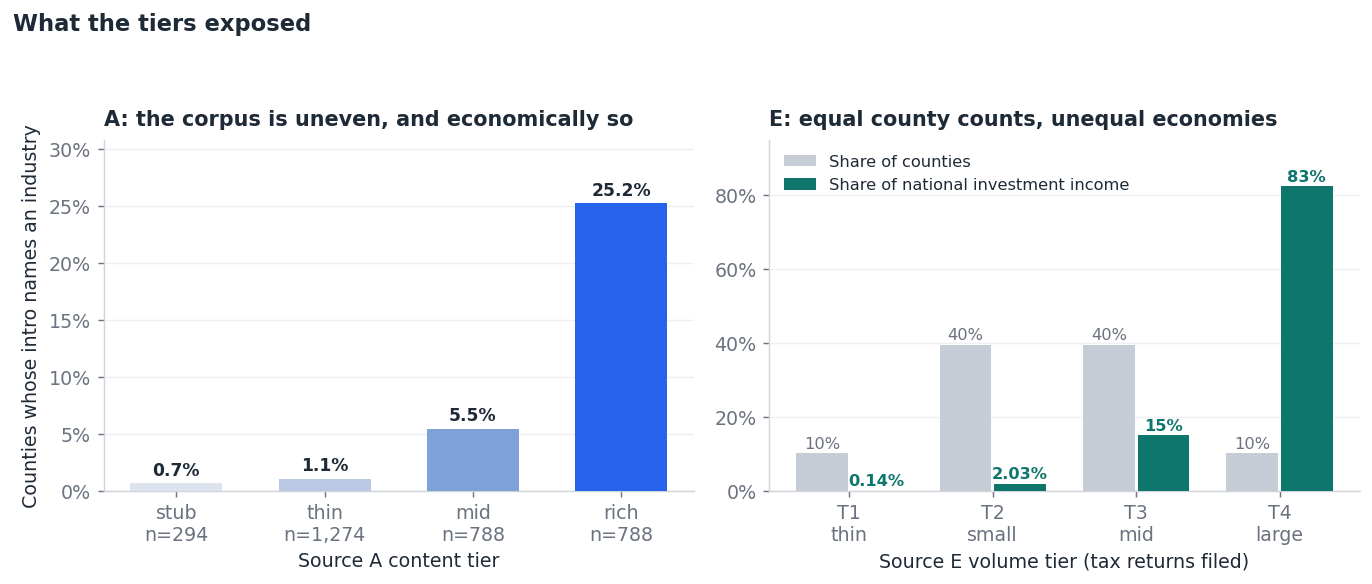

In [3]:
a_sum = a_tiers["summary"]
a_lab = a_tiers["tier_labels"]
e_lab = list(e_tiers["tiers"])
e_sum = e_tiers["tiers"]

fig, (axa, axe) = plt.subplots(1, 2, figsize=(10.6, 4.2))

# --- Source A: industry content by content tier
shares = [a_sum[t]["share_any_industry"] for t in a_lab]
bars = axa.bar(a_lab, shares, width=0.62,
               color=["#dbe3ef", "#b9c9e4", "#7ea2d8", "#2563eb"], zorder=3)
for b, s in zip(bars, shares):
    axa.text(b.get_x() + b.get_width() / 2, s + 0.007, f"{s:.1%}",
             ha="center", fontsize=9.5, fontweight="bold", color=INK)
axa.set_xticks(range(len(a_lab)),
               [f"{t}\nn={a_sum[t]['n_counties']:,}" for t in a_lab])
axa.set_ylim(0, max(shares) * 1.22)
axa.set_ylabel("Counties whose intro names an industry")
axa.set_xlabel("Source A content tier")
axa.set_title("A: the corpus is uneven, and economically so",
              fontsize=11.5, loc="left", pad=8)
axa.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
axa.grid(axis="y", color="#eef0f3", zorder=0)

# --- Source E: share of counties vs share of national investment income
cty = [e_sum[t]["share_of_counties"] for t in e_lab]
inc = [e_sum[t]["share_of_investment_income"] for t in e_lab]
x = range(len(e_lab))
axe.bar([i - 0.19 for i in x], cty, width=0.36, color=BASE,
        label="Share of counties", zorder=3)
axe.bar([i + 0.19 for i in x], inc, width=0.36, color="#0f766e",
        label="Share of national investment income", zorder=3)
for i, (c, v) in enumerate(zip(cty, inc)):
    axe.text(i - 0.19, c + 0.012, f"{c:.0%}", ha="center", fontsize=9, color="#6b7280")
    axe.text(i + 0.19, v + 0.012, f"{v:.2%}" if v < 0.05 else f"{v:.0%}",
             ha="center", fontsize=9, fontweight="bold", color="#0f766e")
axe.set_xticks(list(x), ["T1\nthin", "T2\nsmall", "T3\nmid", "T4\nlarge"])
axe.set_ylim(0, 0.95)
axe.set_xlabel("Source E volume tier (tax returns filed)")
axe.set_title("E: equal county counts, unequal economies",
              fontsize=11.5, loc="left", pad=8)
axe.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
axe.legend(frameon=False, fontsize=9, loc="upper left")
axe.grid(axis="y", color="#eef0f3", zorder=0)

fig.suptitle("What the tiers exposed", x=0.008, y=1.06, ha="left",
             fontsize=12.5, fontweight="bold")
plt.tight_layout()
plt.show()

The right panel is the one to sit with. **T1 and T4 are each about 10% of counties.
T1 holds 0.14% of national investment income; T4 holds 82.6%.** An unweighted
county-level feature and the economy it claims to describe are not the same object —
the national aggregate ratio is 0.156 against an unweighted county mean of 0.107.

Three more things the split turned up, two of which corrected earlier conclusions:

- **The strongest cross-pillar link in the whole project is a large-county
  phenomenon.** B Real Estate LQ × E capital-to-wage runs +0.394 nationally, but
  **+0.476 in T4 and −0.058 in T1**. It does not exist for the counties with the least
  data. Anyone serving rural inventory needs that stated before leaning on B ↔ E.
- **Round 1 had the stability backwards.** I had said small counties were the volatile
  ones. On ranks it is the opposite — Spearman stability *improves* with size
  (0.861 → 0.941), and median year-over-year moves *rise* with size (0.298 → 0.393).
  Which means round 1's proposed fix, weighting by `num_returns`, would have upweighted
  exactly the counties whose values move most between vintages.
- **The dispersion is not sampling noise.** Regressing log dispersion on log median
  returns gives a slope of **+0.026**; pure sampling error would give −0.5. Small
  counties' spread is real economic variation, not thin-data artifact.

**Net from the assigned work:** neither pillar should branch on its groups, Source A
ships one uniform schema, and Source E ships with an explicit warning that its best
cross-pillar result is conditional on county size. The groups did their job by
changing what gets shipped and what gets disclosed — not by becoming part of the model.

---

## 2. The rest of the week, in one line each

- **Grain moved from blocker to non-issue.** Monday's read said joining at market
  grain would destroy the signal; that was half a finding, and the other half
  reverses it. Net cost of a market-grain join: **0.017 R²**. Section 5.
- **The validation stopped being circular.** Everything before this week scored the
  pillars against each other. `E_macro` is now scored against five public outcomes
  outside all six pillars, on held-out states. Sections 3, 4 and 6.
- **Two pillars got cleaned up** — Source D's freight tonnages were county size in
  disguise, Source E's dollar totals likewise. Section 7.

---

## 3. Getting out of the circle

Every validation in this repo before this week was **pillar against pillar**. We

Every validation in this repo before this week was **pillar against pillar**. We
predicted one federal source's features from the other five. That measures whether
six agencies agree with each other. It cannot say whether any of them is *useful*,
and it has a bias baked in: it penalises a source precisely for agreeing with the
others, which is the wrong penalty when the question is "does this predict an
outcome."

There is no way to fix that with a real downstream label — the project is scoped to
public data only, so no such label exists here. The substitute: pick public outcomes
that **no pillar measures**, and predict those.

The five: household broadband adoption, median household income, median age, median
home value, and mean commute time. All from ACS, none constructed from any pillar's
inputs.

**The test is built around one specific objection.** The consumer joins on DMA and
holds millions of impressions per market, so it can estimate a geographic fixed
effect essentially for free — and a fixed effect makes any static geo-keyed feature
look redundant. But a fixed effect has exactly one weakness: **it has no parameter
for a place it has never seen.** So we hold out whole states, and compare against a
model that knows only county size. That is the seam.

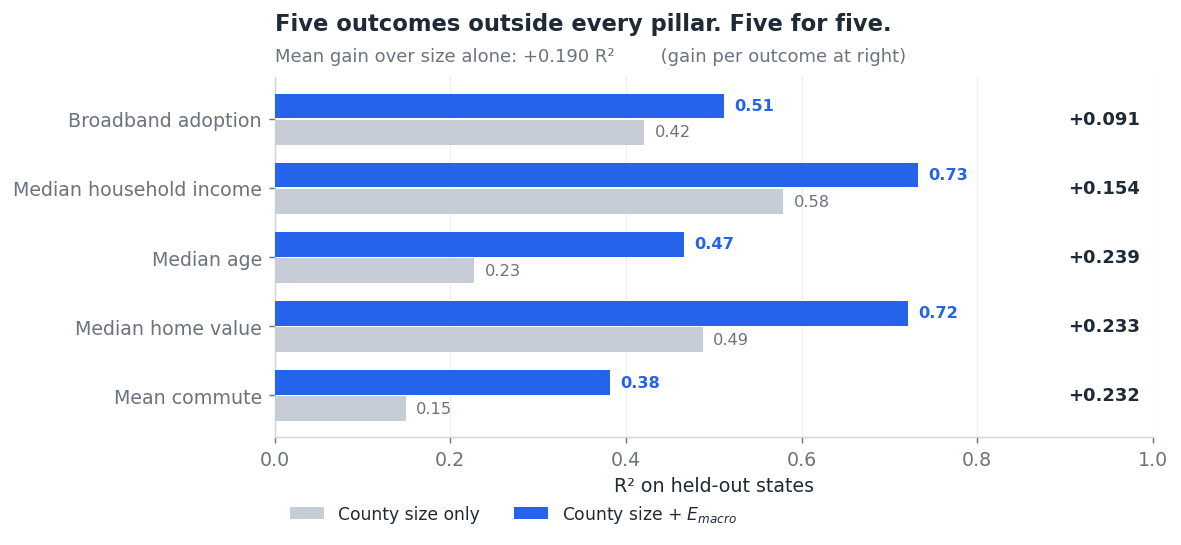

In [4]:
piv = (scores[scores.model.isin(["size", "size_emacro"])]
       .pivot(index="target", columns="model", values="r2_ablated")
       .reindex(ORDER))
lift = (scores[scores.model.eq("size_emacro")]
        .set_index("target")["lift_over_size_ablated"].reindex(ORDER))

fig, ax = plt.subplots(figsize=(9.2, 4.4))
y = range(len(ORDER))
ax.barh([i + 0.19 for i in y], piv["size"], height=0.36, color=BASE,
        label="County size only", zorder=3)
ax.barh([i - 0.19 for i in y], piv["size_emacro"], height=0.36, color=LIFT,
        label="County size + $E_{macro}$", zorder=3)

for i, t in enumerate(ORDER):
    ax.text(piv["size"][t] + 0.012, i + 0.19, f"{piv['size'][t]:.2f}",
            va="center", fontsize=9, color="#6b7280")
    ax.text(piv["size_emacro"][t] + 0.012, i - 0.19, f"{piv['size_emacro'][t]:.2f}",
            va="center", fontsize=9, color=LIFT, fontweight="bold")
    ax.text(0.985, i, f"+{lift[t]:.3f}", transform=ax.get_yaxis_transform(),
            ha="right", va="center", fontsize=10, fontweight="bold", color=INK)

ax.set_yticks(list(y), [LABELS[t] for t in ORDER])
ax.invert_yaxis()
ax.set_xlabel("R² on held-out states")
ax.set_xlim(0, 1.0)
ax.set_title("Five outcomes outside every pillar. Five for five.", pad=26, loc="left")
ax.text(0, 1.045, f"Mean gain over size alone: +{ext['mean_lift_over_size_ablated']:.3f} R²"
        "        (gain per outcome at right)",
        transform=ax.transAxes, fontsize=10, color="#6b7280")
ax.legend(frameon=False, fontsize=9.5, loc="upper left",
          bbox_to_anchor=(0, -0.14), ncol=2)
ax.grid(axis="x", color="#eef0f3", zorder=0)
plt.tight_layout()
plt.show()

Read the grey bar as the fixed-effect model's position and the blue bar as what
`E_macro` adds on top of it. The gap on the right of each row is the whole result.

One sanity check worth stating: an intercept-only model scores **≈0** on these
held-out states. That is the fixed effect being handed a county it has never seen,
behaving exactly as predicted — it has nothing to say.

---

## 4. The discount I applied to my own result

The raw number was better: +0.212. I am reporting **+0.190**, and the difference is
worth a paragraph because it is the kind of thing that gets caught in review rather
than found by the author.

Two pillar columns don't *predict* their target so much as **restate** it:

- `wage_per_return_thousands` (IRS) is average wage income per tax return, which is
  very close to a definition of median household income. Removing it drops that
  outcome's gain from +0.247 to **+0.154** — one column was carrying 38% of the
  apparent result.
- `retirement_destination` (USDA) flags counties with heavy in-migration of people
  aged 60+, which restates age structure. Smaller effect: +0.256 → +0.239.

Both are dropped from their own target's run and kept everywhere else. The headline
is the discounted number.

---

## 5. The grain reversal

This is the part I got wrong on Monday and corrected twice.

### First — what "grain" means here

**Grain is what one row stands for.** Not how detailed the data inside a row is —
the identity of the row itself. Three of them are in play:

| Grain | One row is | Count |
|---|---|---|
| What `E_macro` produces | one US county (`fips_code`) | 3,143 |
| The consumer's training data | one impression / ad request / household | millions |
| The consumer's *geo key* | one Nielsen DMA (media market) | ~210 |

`E_macro` is a lookup table: **geo key → vector**. The downstream model never
consumes a county — it consumes an impression row and joins the vector on whatever
geo key that row carries. So the embedding's grain has to match the key available at
join time, and that is the entire question.

If the impression row only carries `dma`, the table must be re-keyed to 210 rows
before it is usable — 3,143 vectors collapse into 210. If the row carries ZIP, county
is derivable and the table ships unchanged. Current read is that the row does carry
ZIP, which is what makes county grain a live option rather than wishful thinking.

**Why this is load-bearing for a geo embedding specifically.** The consumer holds
millions of impressions per market, so it can estimate a 210-level geographic fixed
effect essentially for free. At DMA grain, any static geo-keyed feature is *exactly
collinear* with that effect by construction — a DMA dummy already captures everything
`E_macro` could say, so `E_macro` adds nothing. At county grain it does not, because
3,143 units is too thin for the consumer to fit its own per-county effect.

Finer grain is therefore not a nice-to-have. **Below DMA is where the feature stops
being redundant with something the consumer already has.** (Section 3's held-out-state
design is the other escape from the same fixed effect: it has no parameter for a
county it has never seen.)

### The penalty has two halves

Collapsing 3,143 keys to ~210 costs something in **two separable ways**, and on
Monday I measured only one:

1. **Fewer distinct rows.** 210 keys means the downstream model can ever see at most
   210 distinct values of this feature block. Measured by retraining on random county
   subsets. Verdict: real and bad — worth **−0.121** on average, and badly unstable at
   that size. On broadband, the outcome closest to the consumer's own domain, it goes
   slightly negative.
2. **Aggregation blur.** Averaging ~15 counties into one market destroys
   within-market variation — and the suburb-outside-New-York-versus-Cleveland
   distinction `E_macro` exists to capture can partly live *inside* a single market.
   Not measured Monday. I said it "could cut either way."

It cuts the other way. Aggregation is worth **+0.105**, which very nearly cancels the
row-count loss.

**One implementation detail that decides whether that number is real: aggregate the
inputs, not the outputs.** A market's location quotient has to be re-derived from
summed employment, not averaged from fifteen counties' quotients. That is why Source
B had to ship raw employment levels this week — see the re-test below.

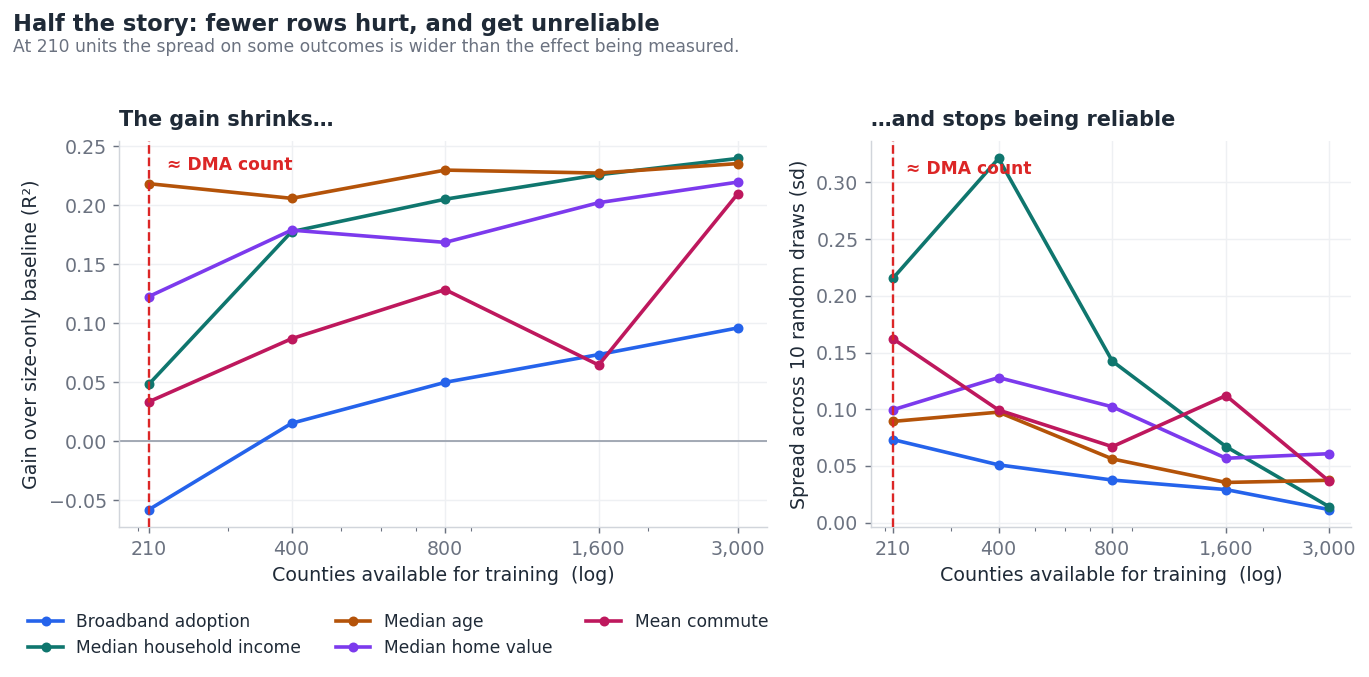

In [5]:
by_size = pd.DataFrame(ext["by_training_size"])

TICKS = [210, 400, 800, 1600, 3000]
palette = ["#2563eb", "#0f766e", "#b45309", "#7c3aed", "#be185d"]

fig, (axl, axr) = plt.subplots(1, 2, figsize=(10.6, 4.3),
                               gridspec_kw={"width_ratios": [1.35, 1]})
for c, t in zip(palette, ORDER):
    d = by_size[by_size.target.eq(t)].sort_values("n_train_units")
    axl.plot(d.n_train_units, d.mean_lift_over_size, "-o", color=c, ms=4.5,
             lw=2.0, label=LABELS[t], zorder=3)
    axr.plot(d.n_train_units, d.sd_lift_over_size, "-o", color=c, ms=4.5,
             lw=2.0, zorder=3)

for ax in (axl, axr):
    ax.set_xscale("log")
    ax.set_xticks(TICKS, ["210", "400", "800", "1,600", "3,000"])
    ax.axvline(210, color=WARN, lw=1.3, ls="--", zorder=4)
    ax.set_xlabel("Counties available for training  (log)")
    ax.grid(color="#eef0f3", zorder=0)

axl.axhline(0, color="#9ca3af", lw=1)
axl.text(228, axl.get_ylim()[1] * 0.95, "≈ DMA count", color=WARN,
         fontsize=9.5, fontweight="bold", va="top")
axl.set_ylabel("Gain over size-only baseline (R²)")
axl.set_title("The gain shrinks…", fontsize=11.5, loc="left", pad=8)
axr.set_ylabel("Spread across 10 random draws (sd)")
axr.set_title("…and stops being reliable", fontsize=11.5, loc="left", pad=8)
axr.text(228, axr.get_ylim()[1] * 0.95, "≈ DMA count", color=WARN,
         fontsize=9.5, fontweight="bold", va="top")

fig.suptitle("Half the story: fewer rows hurt, and get unreliable",
             x=0.008, y=1.06, ha="left", fontsize=12.5, fontweight="bold")
fig.text(0.008, 0.99, "At 210 units the spread on some outcomes is wider than the "
         "effect being measured.", ha="left", fontsize=9.5, color="#6b7280")
fig.legend(frameon=False, fontsize=9.5, loc="lower left",
           bbox_to_anchor=(0.008, -0.12), ncol=3)
plt.tight_layout()
plt.show()

The right panel matters as much as the left. At 210 units the answer depends heavily
on which units you happen to have — that instability, more than the size of the drop,
is what made a market-grain join look unacceptable.

Then the other half got measured:

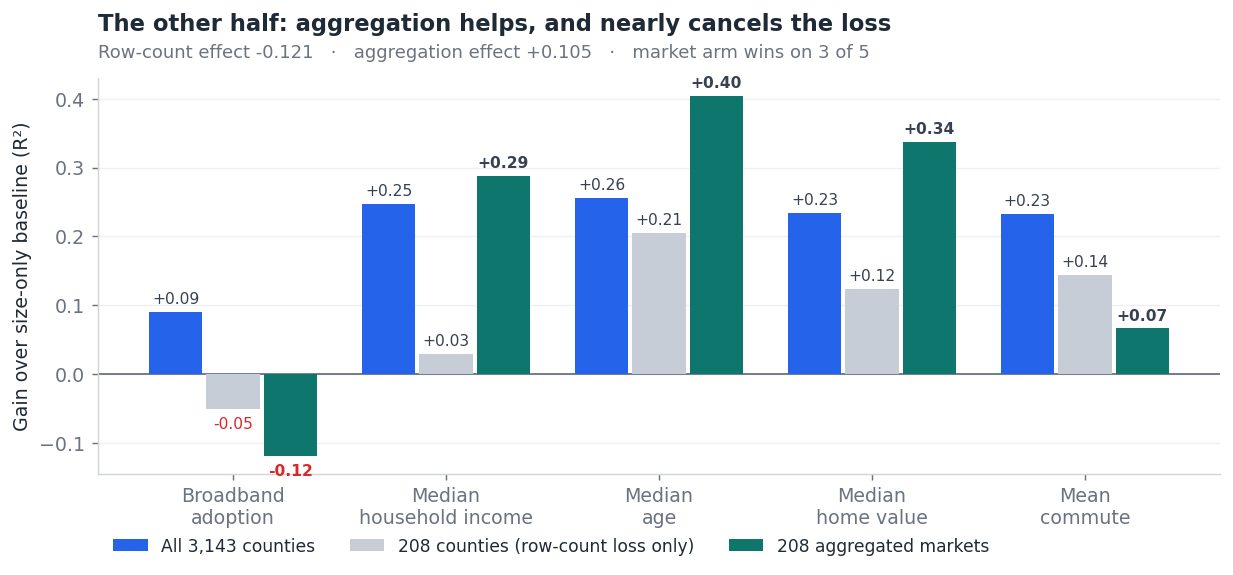

In [6]:
arms = (grain.pivot(index="target", columns="arm", values="mean_lift_over_size")
        .reindex(ORDER))
ARMS = [("county_full", "All 3,143 counties", "#2563eb"),
        ("county_subsample", "208 counties (row-count loss only)", "#c7cdd6"),
        ("market_aggregate", "208 aggregated markets", "#0f766e")]

fig, ax = plt.subplots(figsize=(9.6, 4.6))
x = range(len(ORDER))
for k, (col, lab, c) in enumerate(ARMS):
    off = (k - 1) * 0.27
    vals = arms[col]
    ax.bar([i + off for i in x], vals, width=0.25, color=c, label=lab, zorder=3)
    for i, v in enumerate(vals):
        ax.text(i + off, v + (0.012 if v >= 0 else -0.028), f"{v:+.2f}",
                ha="center", fontsize=8.6,
                color=WARN if v < 0 else "#374151",
                fontweight="bold" if col == "market_aggregate" else "normal")

ax.axhline(0, color="#6b7280", lw=1)
ax.set_xticks(list(x), [LABELS[t].replace(" ", "\n", 1) for t in ORDER])
ax.set_ylabel("Gain over size-only baseline (R²)")
ax.set_title("The other half: aggregation helps, and nearly cancels the loss",
             pad=26, loc="left")
ax.text(0, 1.05, f"Row-count effect {gst['row_count_effect']:+.3f}   ·   "
        f"aggregation effect {gst['aggregation_effect']:+.3f}   ·   "
        "market arm wins on 3 of 5",
        transform=ax.transAxes, fontsize=10, color="#6b7280")
ax.legend(frameon=False, fontsize=9.5, loc="upper left", bbox_to_anchor=(0, -0.12), ncol=3)
ax.grid(axis="y", color="#eef0f3", zorder=0)
plt.tight_layout()
plt.show()

Compare the grey bar to the teal one — same 208 rows in both, the only difference is
whether those rows are lone counties or aggregated markets. **Median home value goes
+0.12 → +0.34. Median age goes +0.21 → +0.41.** The mechanism is not exotic:
population-weighted aggregation turns sparse, noisy county columns — suppressed BLS
cells, single-article Wikipedia flags — into stable continuous shares, and does the
same favour to the outcome being predicted.

**Then I tried to break it.** The obvious objection was that most columns were being
*approximated* at market level rather than properly re-derived, which would make the
market arm look artificially good. So Source B was re-ingested to ship raw employment
levels, moving 72 of 118 columns from approximated to correctly re-derived. Re-running
everything moved the aggregation effect by **0.001**, and no outcome changed sign.

That was expected to cost 2–3 days. It cost one download and two script changes.

**What still stands as a caveat:** the 208 market groups are k-means clusters of
county centroids, matched to DMA cardinality — they are *not* DMAs, because that
delineation is proprietary. Real markets follow media boundaries and are less
spatially compact, and the aggregated outcome is genuinely less noisy than a county
one. Both biases favour the market arm, so **+0.105 is an upper bound.**

How much does that matter? Two different thresholds, worth keeping apart:

- For market grain to be a **blocker** again — signal destroyed rather than merely
  reduced — essentially the whole +0.105 would have to be an artifact of the proxy.
  That is a large claim and I don't think the biases named above are anywhere near
  big enough to support it.
- For county grain to be **strictly better**, the overstatement only has to be
  **0.017** — that is the gap between the full-county arm (+0.212) and the market
  arm (+0.195). That is a small enough margin that I would not argue the market arm
  is *better*, only that it is not disqualifying.

---

## 6. Where the model cannot win, and why that is fine

One result looks alarming until you see what is under it: on the smallest counties,
the size-only baseline scores **negative** R². Something is badly wrong there — but
it is wrong with the data, not the model.

ACS publishes a margin of error with every estimate. Those are now ingested alongside
the values, which lets us split each outcome's variance into signal and sampling
noise. In the smallest population decile, **30% of the variance is sampling noise** —
error no model can ever explain. By the largest decile that is under 1%.

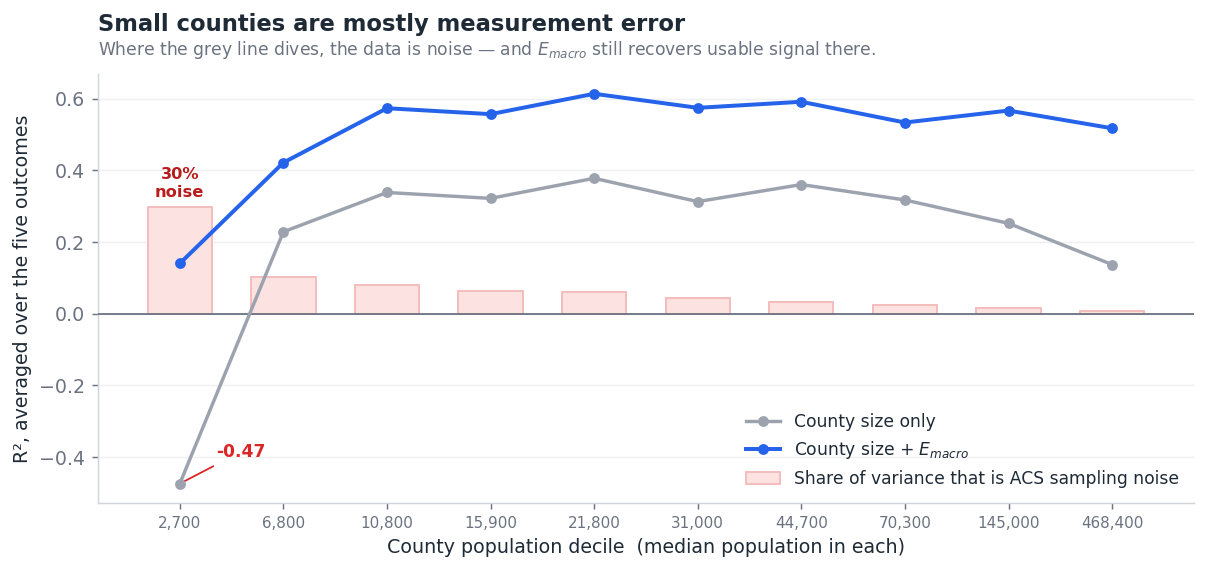

In [7]:
dec = (decile.groupby("population_decile")
       .agg(median_population=("median_population", "mean"),
            noise_share=("noise_share", "mean"),
            r2_size=("r2_size", "mean"),
            r2_size_emacro=("r2_size_emacro", "mean"))
       .reset_index())

fig, ax = plt.subplots(figsize=(9.4, 4.5))
ax.bar(dec.population_decile, dec.noise_share, width=0.62, color="#fde2e2",
       edgecolor="#f5b8b8", label="Share of variance that is ACS sampling noise", zorder=2)
ax.plot(dec.population_decile, dec.r2_size, "-o", color="#9ca3af", ms=5, lw=1.9,
        label="County size only", zorder=4)
ax.plot(dec.population_decile, dec.r2_size_emacro, "-o", color=LIFT, ms=5, lw=2.2,
        label="County size + $E_{macro}$", zorder=5)
ax.axhline(0, color="#6b7280", lw=1, zorder=3)

worst = dec.iloc[0]
ax.annotate(f"{worst.r2_size:.2f}", xy=(1, worst.r2_size), xytext=(1.35, -0.40),
            fontsize=9.5, color=WARN, fontweight="bold",
            arrowprops=dict(arrowstyle="-", color=WARN, lw=1))
ax.text(1.0, worst.noise_share + 0.03, f"{worst.noise_share:.0%}\nnoise",
        ha="center", fontsize=9, color="#b91c1c", fontweight="bold")

ax.set_xticks(range(1, 11),
              [f"{int(p):,}" for p in dec.median_population.round(-2)], fontsize=8.4)
ax.set_xlabel("County population decile  (median population in each)")
ax.set_ylabel("R², averaged over the five outcomes")
ax.set_title("Small counties are mostly measurement error", pad=24, loc="left")
ax.text(0, 1.045, "Where the grey line dives, the data is noise — and $E_{macro}$ still "
        "recovers usable signal there.",
        transform=ax.transAxes, fontsize=9.5, color="#6b7280")
ax.legend(frameon=False, fontsize=9.5, loc="lower right")
ax.grid(axis="y", color="#eef0f3", zorder=0)
plt.tight_layout()
plt.show()

Two things follow. First, the negative baseline on tiny counties is a property of ACS,
not a defect in the pipeline. Second — and more useful — `E_macro` stays positive in
exactly the decile where the size baseline collapses, which is what you would want
from a feature meant to describe places that a size proxy describes badly.

It also sets an honest ceiling: on the smallest counties no model can exceed R² ≈ 0.70
no matter how good the features are.

---

## 7. Plumbing, briefly

Work that doesn't change the story but does change what ships:

- **Source D's freight tonnages were county size wearing a freight label.** All ten
  raw tonnage columns moved into the size control. Measured cost of removing them:
  nothing. Normalising them per capita turned out to be a re-expression, not a fix.
- **Commodity shares replaced them** — 5 of 10 clear the size-free bar that none of
  the raw columns cleared, and the gain routes almost entirely to Source B, which is
  interpretable rather than mysterious.
- **Source E's capital-to-wage ratio was decomposed** into its components, plus a
  five-year panel — which is what made the tier work in Section 1 possible. Its
  remaining dollar totals moved into the size control on the same principle as D's.
- **Source B now ships raw employment levels**, so its 40 location quotients can be
  re-derived at any grain instead of approximated. This is what made the grain
  re-test above trustworthy.
- **Source A** was also measured for marginal value against a baseline that already
  contains the other five pillars — the harder question than the tier split — and the
  last embedding-era artifacts were retired repo-wide.
- **The archive notebook was re-read against regenerated outputs.** Several Section 8
  numbers had drifted after D and E moved into the size control; corrected.

### What's next, regardless

1. Re-derive Source D's two partner-concentration indices from the partner-level flow
   table — the last columns that are still approximated at market grain with an
   underlying quantity to re-sum.
2. Build the assembly step. The go/no-go evidence now exists, which was the thing
   gating it.
3. Keep the grain caveat live: if a real DMA delineation ever becomes available, the
   market-arm result is worth re-running against it once.

---

*Sources: `analysis-output/cross-source/external-target-findings.md` (§10–§20),
`analysis-output/source-d/source-d-findings.md`,
`analysis-output/source-e/source-e-findings.md`, `docs/plans/dma_regrain.md`.*